In [14]:
import os
from pathlib import Path
# Set the project folder
PRJ_PATH = Path(os.path.abspath('')).parent
INC_PATH = os.path.join(PRJ_PATH, "inc")
IMG_PATH = os.path.join(PRJ_PATH, "img")
DATA_PATH = os.path.join(PRJ_PATH, "data")
import sys
# Add to path
if INC_PATH not in sys.path: sys.path.append(INC_PATH)
from constants import *
import AdriaArray as AA
import pickle

import seisbench.models as sbm

def load_data(path : str):
  # Load the data
  with open(os.path.join(path), 'rb') as f:
    data = pickle.load(f)
  return data

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ANT_PATH = os.path.join(DATA_PATH, ANT_STR)
DATA = []
for m in [PHASENET_STR, EQTRANSFORMER_STR]:
  for w in [INSTANCE_STR, ORIGINAL_STR, SCEDC_STR, SCEDC_STR]:
    MODEL = AA.get_model(m, w)
    for d in os.listdir(ANT_PATH):
      for n in os.listdir(os.path.join(ANT_PATH, d)):
        for s in os.listdir(os.path.join(ANT_PATH, d, n)):
          f = os.path.join(ANT_PATH, d, n, s, "_".join([d, n, s, m, w]) + "." + PICKLE_EXT)
          data = load_data(f)
          for t in ["P", "S"]:
            for i in np.linspace(0.2, 1, 9):
              DATA.append((m, w, d, n, s, t, i, MODEL.picks_from_annotations(data, threshold=i, phase=t)))
DATA = pd.DataFrame(DATA, columns=["MODEL", "WEIGHT", "DATE", "NETWORK", "STATION", "WAVE", "THRESHOLD", "DATA"])

/home/ken/anaconda3/envs/OGS/lib/python3.12/site-packages/seisbench/models/base.py:489: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_pt}"

PhaseNet Model trained on INSTANCE for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adjusted.
When using this model, please reference the SeisBench publications listed at https://github.com/seisbench/seisbench

Jannes Münchmeyer, Jack Woollam (munchmej@gfz-potsdam.de, jack.woollam@kit.edu)
/home/ken/Documents/PhD/data/annotated/230601/4P/IT09A/230601_4P_IT09A_PhaseNet_instance.pkl
/home/ken/Documents/PhD/data/annotated/230601/4P/IT08A/230601_4P_IT08A_PhaseNet_instance.pkl
/home/ken/Documents/PhD/data/annotated/230602/4P/IT09A/230602_4P_IT09A_PhaseNet_instance.pkl
/home/ken/Documents/PhD/data/annotated/230602/4P/IT08A/230602_4P_IT08A_PhaseNet_instance.pkl
PhaseNet Original PhaseNet model from Zhu et al. (2018). Originally published under MIT License. Original available at https://github.com/AI4EPS/PhaseNet/tree/master/model/190703-214543 . 

Converted to SeisBenc

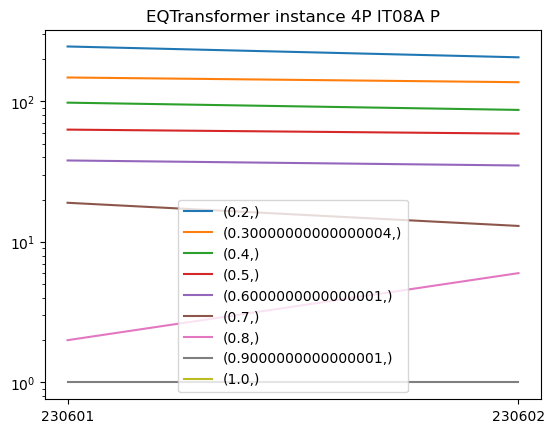

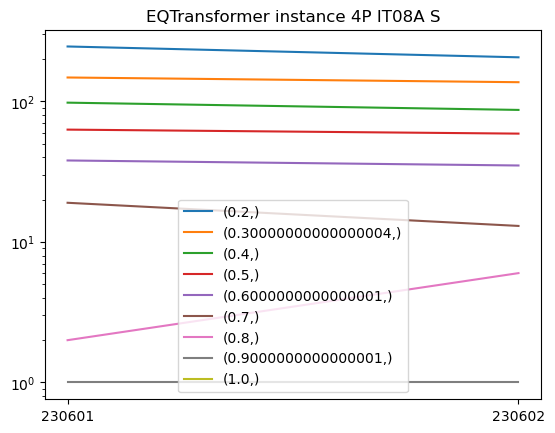

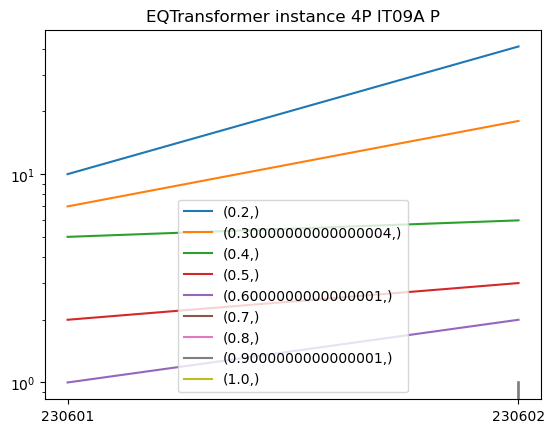

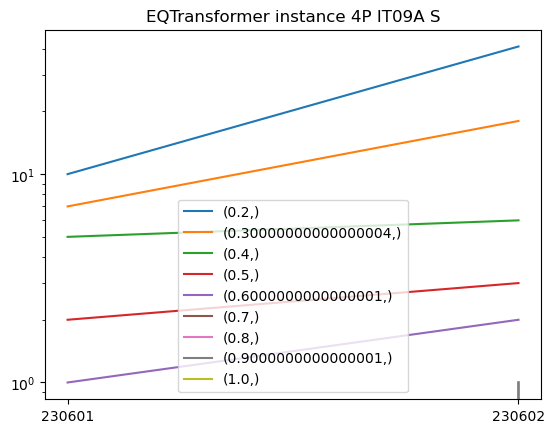

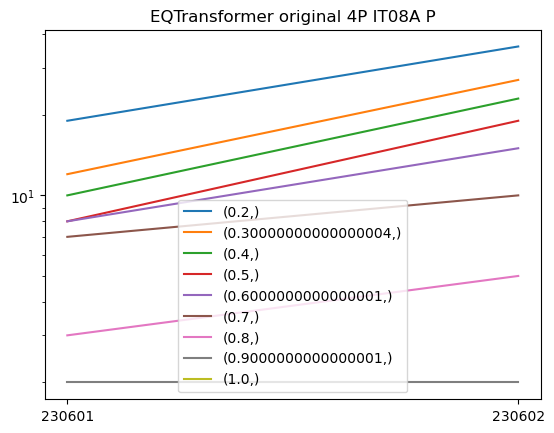

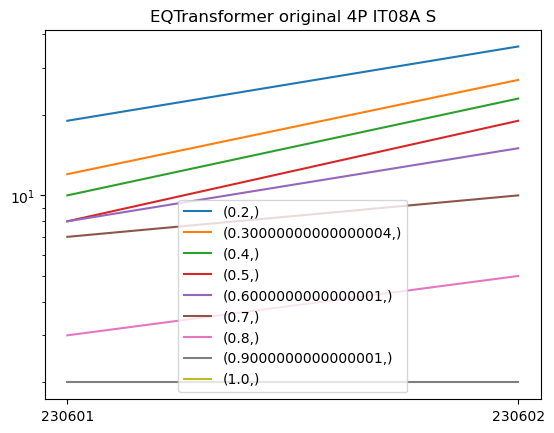

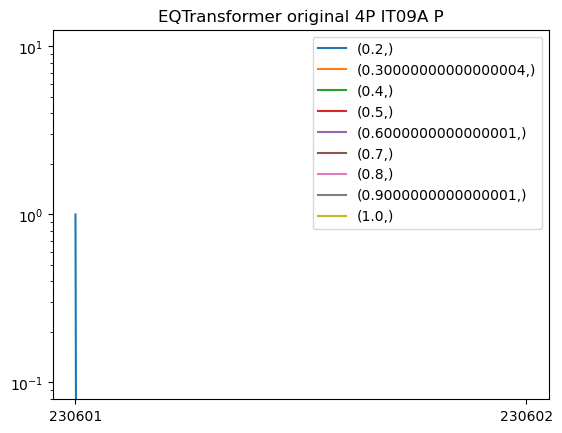

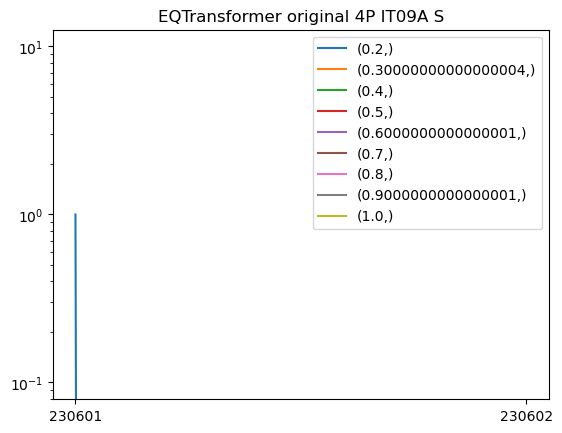

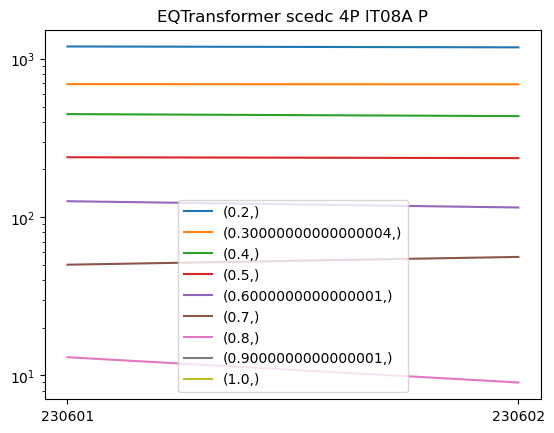

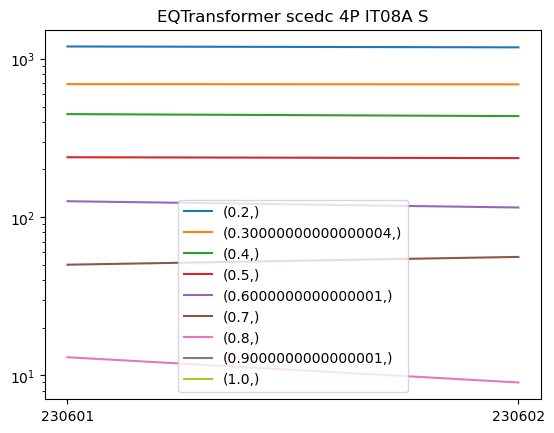

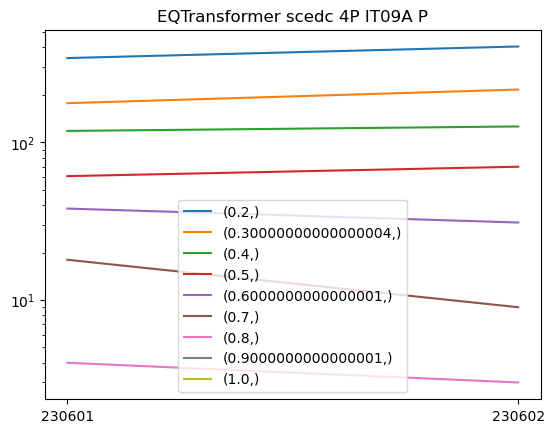

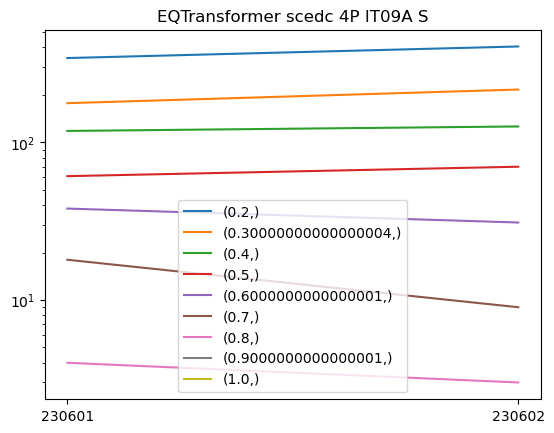

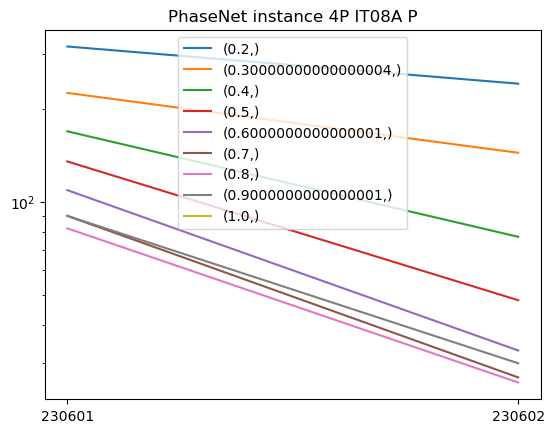

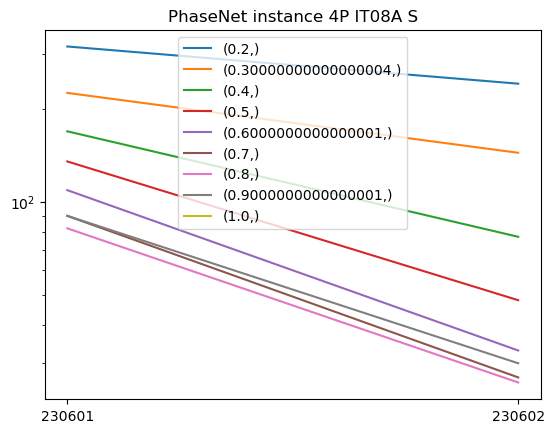

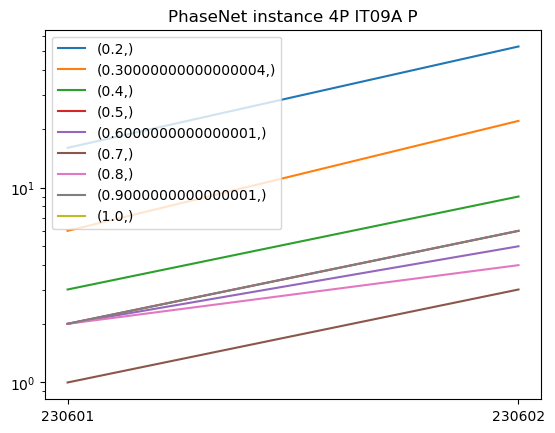

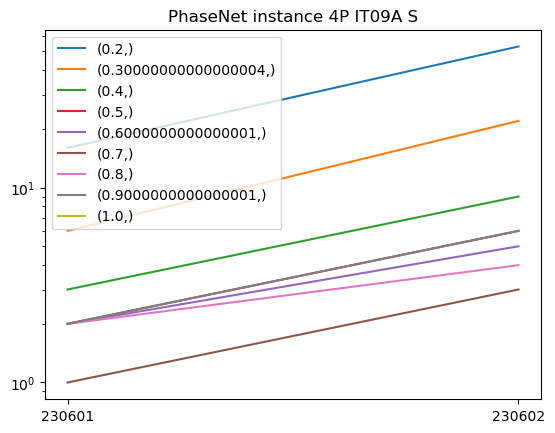

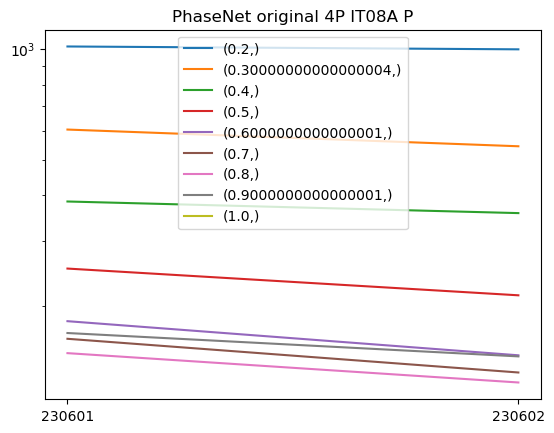

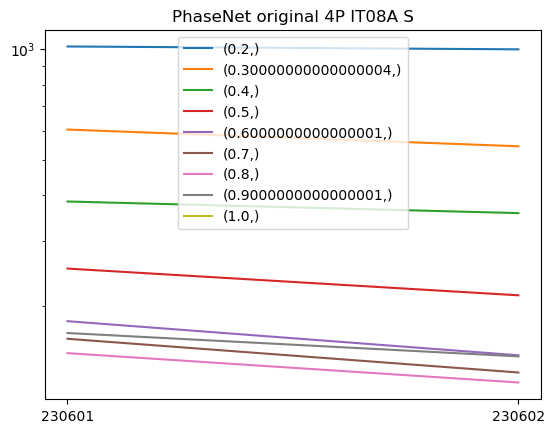

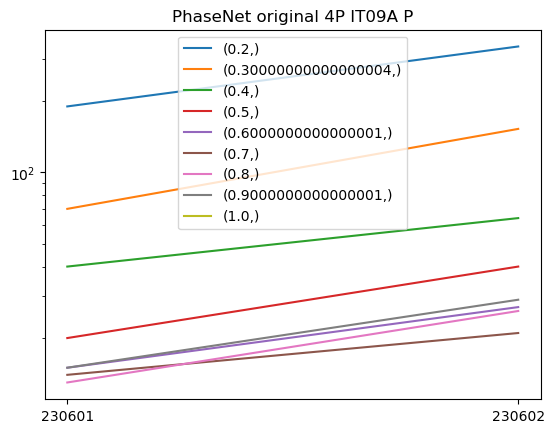

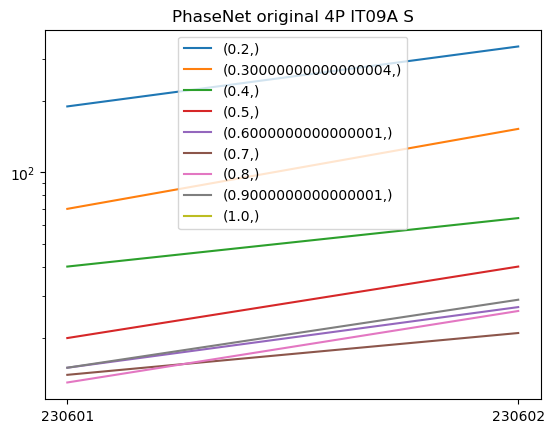

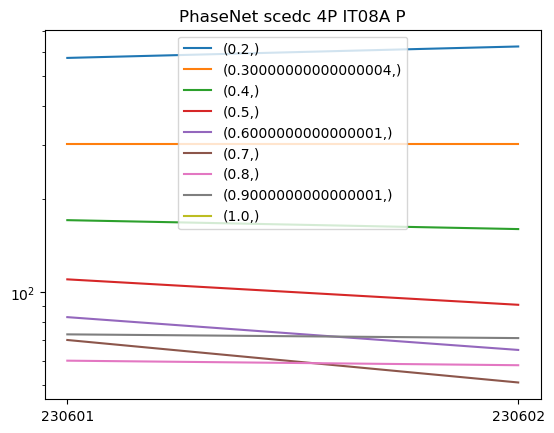

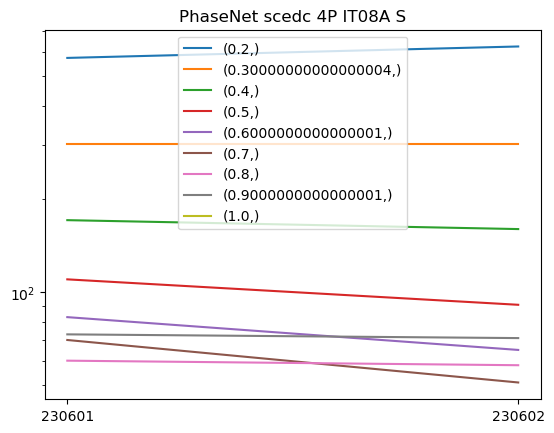

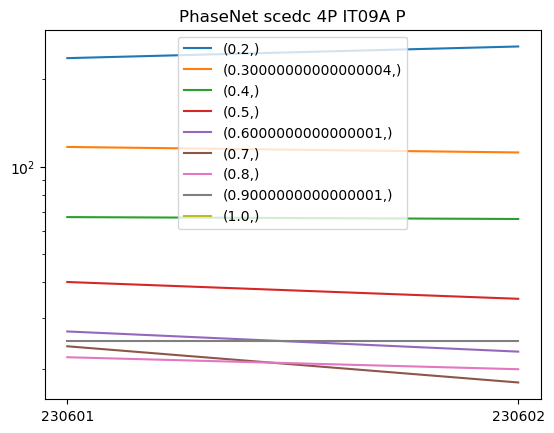

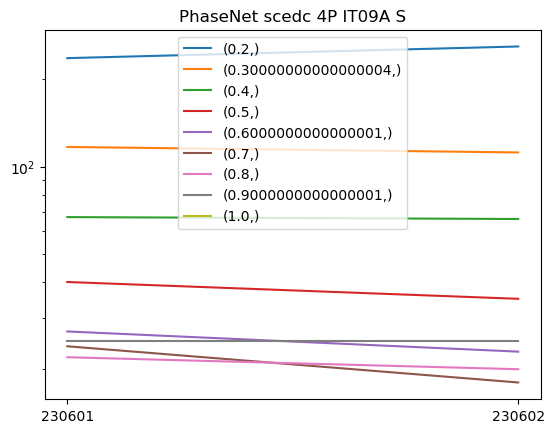

<Figure size 640x480 with 0 Axes>

In [57]:
x = DATA["DATE"].unique()
for DAT in DATA.groupby(["MODEL", "WEIGHT", "NETWORK", "STATION", "WAVE"]):
  m, w, n, s, t = DAT[0]
  plt.title(" ".join(DAT[0]))
  for D in DAT[1].groupby(["THRESHOLD"]):
    i = D[0]
    y = [len(res) for res in D[1]["DATA"][:len(x)]]
    plt.plot(x, y, label="_".join([str(i)]))
  plt.yscale("log")
  plt.legend()
  plt.show()
  plt.clf()